# Network Threat Detection Using Machine Learning

## Project Overview

This project focuses on detecting malicious network activities using Machine Learning techniques. 
The system analyzes network traffic data and classifies whether a connection is normal or an attack.

The project uses the NSL-KDD dataset and applies preprocessing, visualization, feature engineering, and machine learning algorithms to build an intrusion detection system.

## Problem Statement

With the rapid growth of internet usage and digital systems, cyber attacks have become increasingly common. 
Traditional rule-based security systems often fail to detect unknown or evolving threats.

This project aims to develop a Machine Learning-based threat detection system capable of identifying malicious network behavior automatically and efficiently.

## Objectives

- To analyze network traffic data
- To preprocess and clean cybersecurity datasets
- To visualize attack patterns and feature relationships
- To train multiple Machine Learning models
- To compare model performances
- To identify the best-performing algorithm
- To build a deployable intrusion detection system using Streamlit

## Expected Outcomes

The system can:

- Detect malicious network traffic
- Classify normal and attack connections
- Reduce manual monitoring efforts
- Assist cybersecurity analysts
- Improve network security monitoring
- Provide real-time prediction capability through deployment

# Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

import joblib

import warnings 
warnings.filterwarnings("ignore")

## Defining Dataset Columns

The NSL-KDD dataset does not contain predefined column headers. 
Therefore, all feature names are manually assigned for better readability and analysis.

In [2]:
columns = [
'duration','protocol_type','service','flag','src_bytes',
'dst_bytes','land','wrong_fragment','urgent','hot',
'num_failed_logins','logged_in','num_compromised',
'root_shell','su_attempted','num_root',
'num_file_creations','num_shells','num_access_files',
'num_outbound_cmds','is_host_login','is_guest_login',
'count','srv_count','serror_rate','srv_serror_rate',
'rerror_rate','srv_rerror_rate','same_srv_rate',
'diff_srv_rate','srv_diff_host_rate','dst_host_count',
'dst_host_srv_count','dst_host_same_srv_rate',
'dst_host_diff_srv_rate','dst_host_same_src_port_rate',
'dst_host_srv_diff_host_rate','dst_host_serror_rate',
'dst_host_srv_serror_rate','dst_host_rerror_rate',
'dst_host_srv_rerror_rate','attack','level'
]

## Dataset Used

Dataset Name: NSL-KDD Dataset

The NSL-KDD dataset is a benchmark dataset used for intrusion detection research. 
It contains both normal and malicious network traffic records with multiple network-related features.

The dataset includes:
- Training dataset
- Testing dataset
- Various attack categories
- Network traffic attributes

In [3]:
train_df = pd.read_csv(r"C:\Users\anike\Network Threat Detection\Dataset/KDDTrain+.txt",names=columns)
test_df = pd.read_csv(r"C:\Users\anike\Network Threat Detection\Dataset/KDDTest+.txt",names=columns)

In [4]:
train_df.head()
test_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,mscan,11


In [5]:
train_df["protocol_type"].value_counts()

protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64

In [6]:
 train_df.shape

(125973, 43)

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [8]:
train_df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,level
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [9]:
train_df.isnull().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [10]:
train_df.duplicated().sum()

np.int64(0)

In [11]:
train_df.drop_duplicates(inplace=True)

## Attack Distribution Analysis

The attack column is analyzed to understand the frequency of normal and malicious network traffic.

In [12]:
train_df['attack'].value_counts()

attack
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

## Converting Attack Labels

The attack labels are converted into binary classes:
- 0 → Normal Traffic
- 1 → Attack Traffic

This simplifies the classification problem and improves model training efficiency.

In [13]:
train_df['attack'] = train_df['attack'].apply(lambda x: 0 if x == 'normal' else 1)

test_df['attack'] = test_df['attack'].apply(lambda x: 0 if x == 'normal' else 1)

In [14]:
train_df['attack'].value_counts()

attack
0    67343
1    58630
Name: count, dtype: int64

In [15]:
categorical_cols = ['protocol_type','service','flag']

In [16]:
for col in categorical_cols:

    encoder = LabelEncoder()

    combined = pd.concat([
        train_df[col],
        test_df[col]
    ])

    encoder.fit(combined)

    train_df[col] = encoder.transform(train_df[col])

    test_df[col] = encoder.transform(test_df[col])

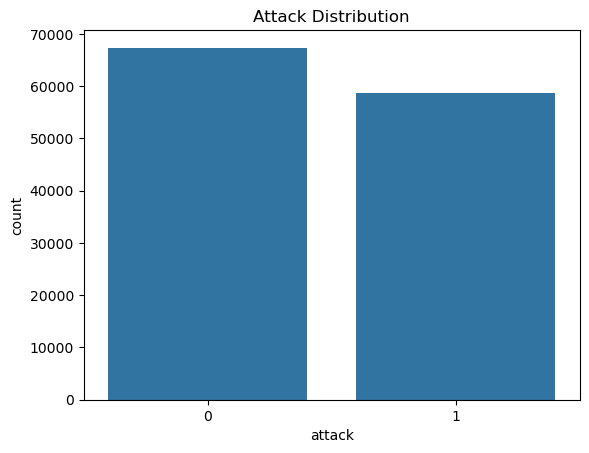

In [17]:
sns.countplot(x=train_df['attack'])

plt.title("Attack Distribution")

plt.show()

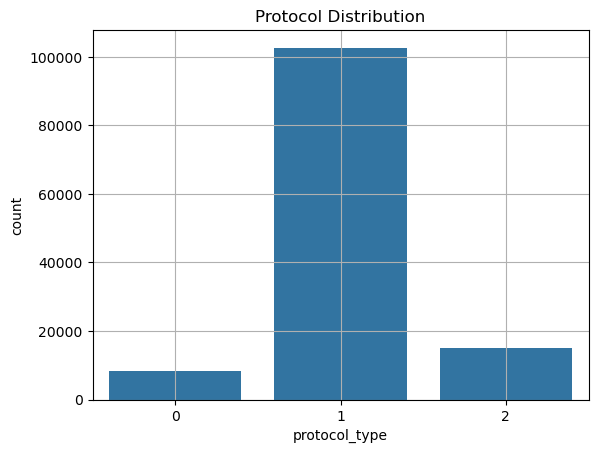

In [18]:
sns.countplot(x=train_df['protocol_type'])

plt.title("Protocol Distribution")
plt.grid()
plt.show()

In [20]:
train_df["protocol_type"].value_counts()

protocol_type
1    102689
2     14993
0      8291
Name: count, dtype: int64

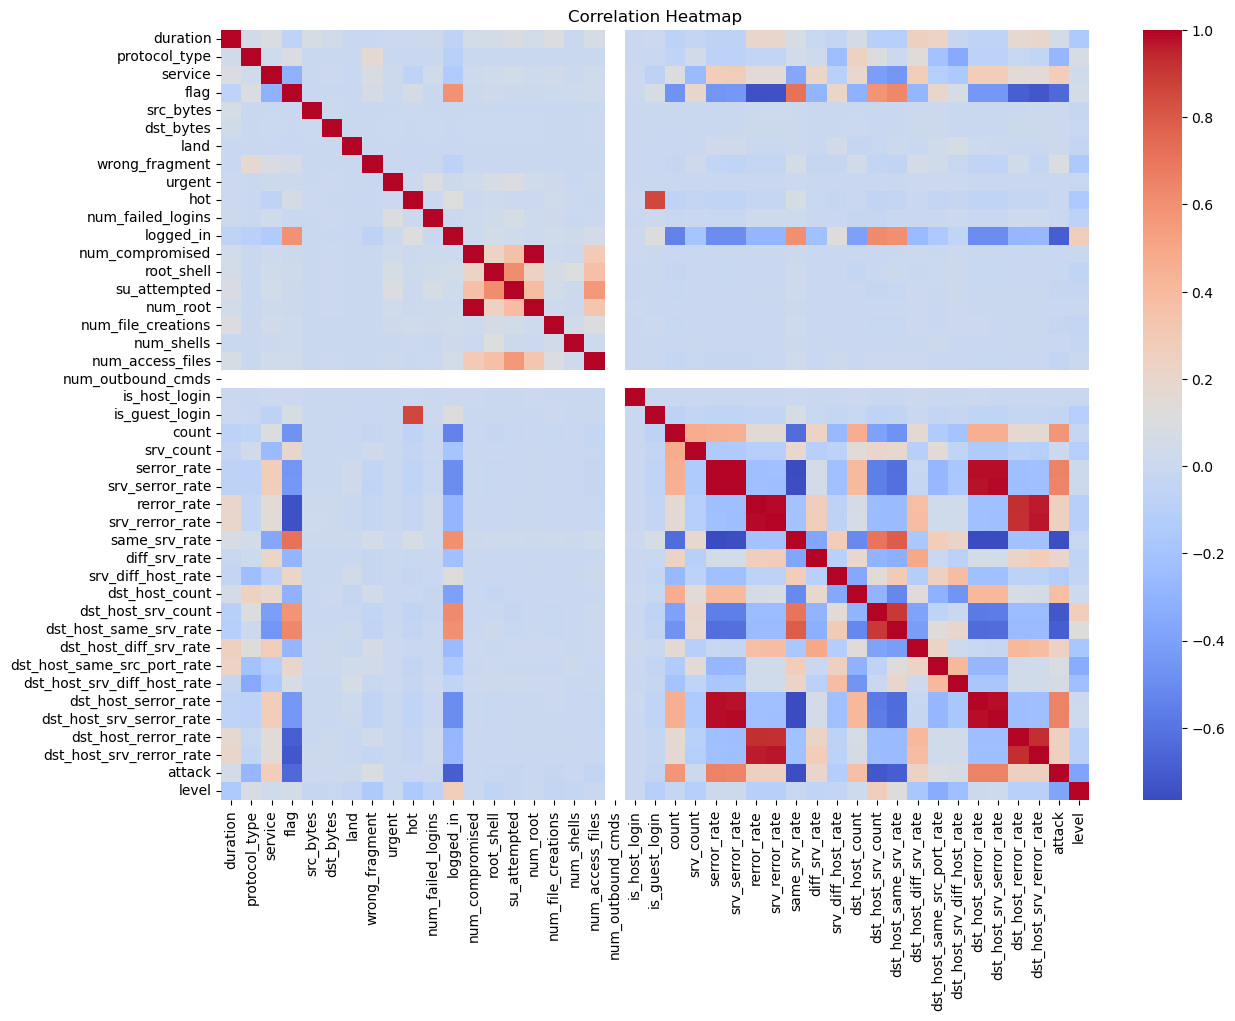

In [21]:
plt.figure(figsize=(14,10))

sns.heatmap( train_df.corr(),cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

Observation:
A white separation line appeared in the heatmap due to constant-value features having undefined correlations.

In [22]:
constant_columns = [col for col in train_df.columns
    if train_df[col].nunique() == 1]

print("Constant Columns:", constant_columns)

Constant Columns: ['num_outbound_cmds']


In [23]:
train_df.drop(columns=constant_columns,inplace=True)

test_df.drop(columns=constant_columns,inplace=True)

## Improved Correlation Analysis

After identifying and removing the constant feature (num_outbound_cmds), the correlation heatmap became cleaner and more meaningful.

The removed feature contained the same value across all records, resulting in undefined correlation values. Since it did not contribute any useful information for prediction, it was removed from the dataset.

The updated heatmap provides a better understanding of relationships between network traffic features.

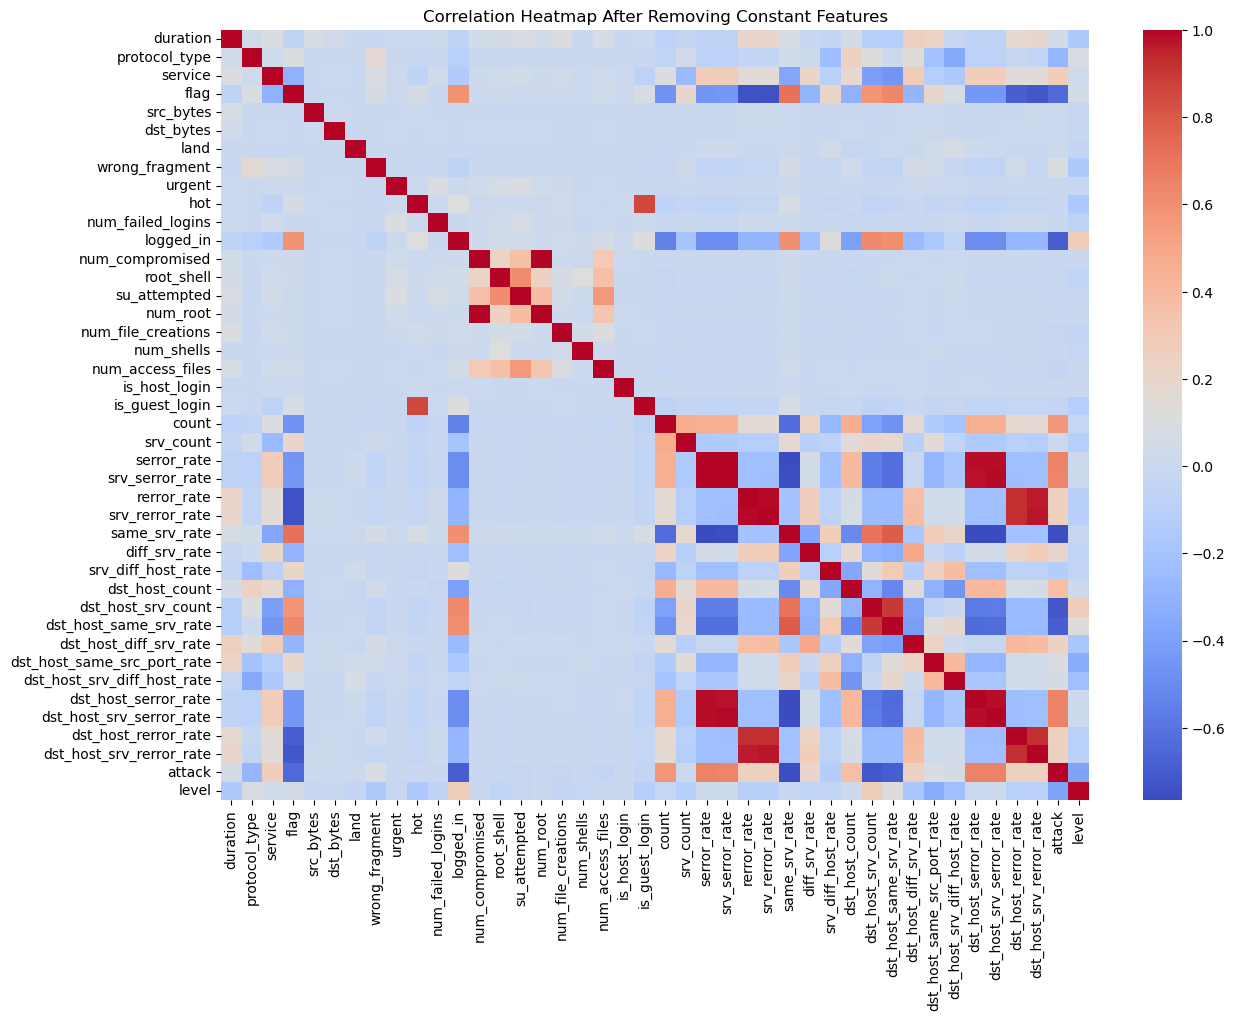

In [24]:
plt.figure(figsize=(14,10))

sns.heatmap(train_df.corr(),cmap='coolwarm')

plt.title("Correlation Heatmap After Removing Constant Features")

plt.show()

## Observation

The boxplot reveals the presence of several extreme values in the selected feature.

These outliers may represent abnormal network activity, high traffic volume, or attack-related behavior.

Since cybersecurity datasets naturally contain unusual traffic patterns, these values are retained for further analysis.

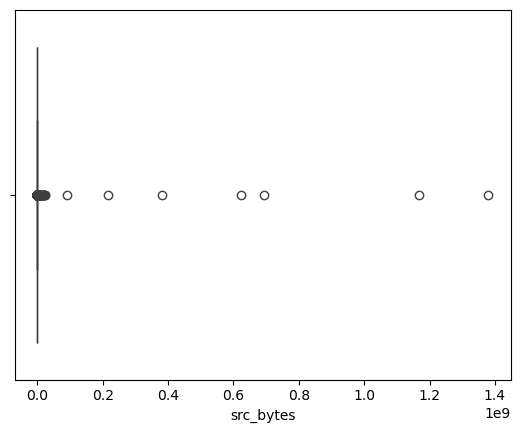

In [25]:
sns.boxplot(x=train_df['src_bytes'])

plt.show()

In [26]:
important_features = [
    'duration',
    'protocol_type',
    'src_bytes',
    'dst_bytes',
    'count',
    'srv_count',
    'serror_rate',
    'same_srv_rate',
    'dst_host_count',
    'dst_host_srv_count'
]

X_train = train_df[important_features]
X_test = test_df[important_features]

y_train = train_df['attack']
y_test = test_df['attack']

In [27]:
print(X_train.shape)
print(X_test.shape)

(125973, 10)
(22544, 10)


## Observation

After applying StandardScaler, all features are transformed to a common scale with a mean close to 0 and a standard deviation close to 1.

This prevents features with larger numerical values from dominating the learning process and helps Machine Learning algorithms perform more effectively.

In [28]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

## Machine Learning Model Training

After preprocessing and feature scaling, multiple Machine Learning algorithms are trained to classify network traffic as normal or malicious.

The following algorithms are used:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

Training multiple models allows us to compare their performance and identify the most suitable algorithm for network threat detection.

In [29]:
models = {

    "Logistic Regression":
        LogisticRegression(random_state=42),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "XGBoost":
        XGBClassifier(random_state=42)

}

results = {}
predictions = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    predictions[name] = prediction

    accuracy = accuracy_score(
        y_test,
        prediction
    )

    results[name] = accuracy

    print(f"{name}: {accuracy}")

Logistic Regression: 0.7236071682044003
Decision Tree: 0.7623757984386089
Random Forest: 0.7577625975869411
XGBoost: 0.791208303761533


In [30]:
Logistic_Regression = round(0.7236071682044003,2)*100
Decision_Tree = round(0.7623757984386089,2)*100
Random_Forest = round(0.7577625975869411,2)*100
XGBoost = round(0.791208303761533,2)*100

In [31]:
x=[Logistic_Regression ,Decision_Tree,Random_Forest,XGBoost]
y=["Logistic_Regression" ,"Decision_Tree","Random_Forest","XGBoost"]

<Axes: >

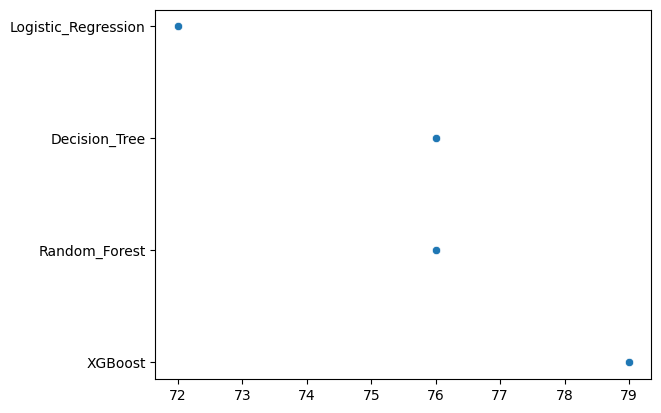

In [32]:
sns.scatterplot(x=x,y=y)

## Best Model Selection

Among all evaluated Machine Learning algorithms, the XG Boost  model achieved the highest accuracy of approximately 79.0 %.

Therefore, XG Boost was selected as the final model for further evaluation and deployment.

In [37]:
best_model_name = max(
    results,
    key=results.get
)

best_model = models[
    best_model_name
]


best_accuracy = results[
    best_model_name
]

print("Best Model :", best_model_name)
print("Accuracy   :", round(best_accuracy,4)*100)

Best Model : XGBoost
Accuracy   : 79.12


## Classification Report

The classification report provides additional evaluation metrics such as:

- Precision
- Recall
- F1-Score

These metrics provide a more detailed understanding of model performance and prediction quality.

In [38]:
best_prediction = predictions[
    best_model_name
]

print(
    classification_report(
        y_test,
        best_prediction
    )
)

              precision    recall  f1-score   support

           0       0.68      0.97      0.80      9711
           1       0.97      0.66      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.82      0.81      0.79     22544
weighted avg       0.84      0.79      0.79     22544



In [39]:
# best_model = models[
#     best_model_name
# ]

# feature_names = train_df.drop(
#     columns=['attack']
# ).columns

# feature_importance = pd.Series(
#     best_model.feature_importances_,
#     index=feature_names
# )

# feature_importance.sort_values(
#     ascending=False
# ).head().plot(
#     kind='barh',
#     figsize=(8,6)
# )

# plt.title("Top 5 Important Features")

# plt.show()

## Model Saving

The trained model and scaler are saved using Joblib.

Saving the model allows it to be reused without retraining and enables deployment through a web application.

In [40]:
import joblib

joblib.dump(
    best_model,
    "network_threat_model.joblib"
)

joblib.dump(
    scaler,
    "scaler.joblib"
)

print("Model Saved Successfully")

Model Saved Successfully
